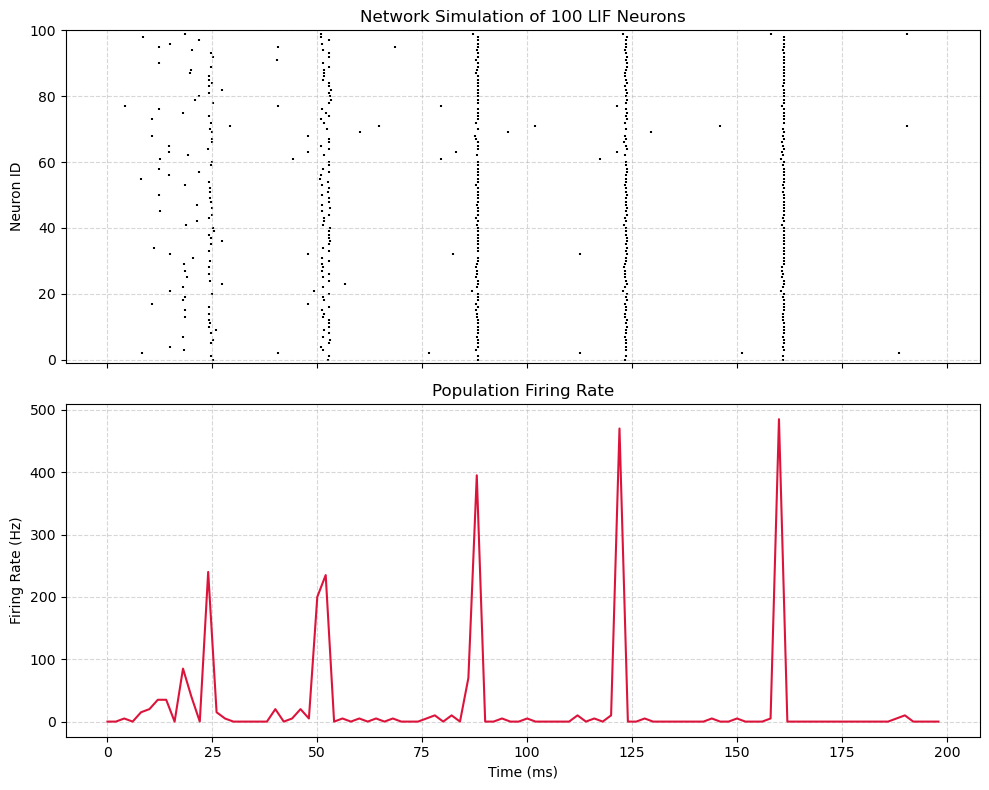

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Simulation and Network Parameters
# ==========================================
N = 100          # Number of neurons
T = 200.0        # Total simulation time (ms)
dt = 0.1         # Time step for Euler integration (ms)
time = np.arange(0, T, dt)
steps = len(time)

# Neuron parameters
tau_m = 20.0     # Membrane time constant (ms)
V_rest = -70.0   # Resting membrane potential (mV)
V_th = -50.0     # Spike threshold (mV)
V_reset = -65.0  # Reset potential after a spike (mV)
R = 1.0          # Membrane resistance (GOhm)

# External input current (mean + noise to create realistic firing)
I_ext_mean = 21.0  # nA
I_ext_noise = 2.0  # Noise amplitude

# Synaptic parameters
connection_prob = 0.1  # 10% chance of connection between any two neurons
weight_scale = 0.5     # Synaptic weight strength (mV)

# ==========================================
# 2. Initialization
# ==========================================
# Initialize membrane voltages randomly between V_reset and V_th
V = np.random.uniform(V_reset, V_th, size=N)

# Random sparse connectivity matrix (Directed Graph)
# W[j, i] represents the connection FROM neuron i TO neuron j
W = np.random.binomial(1, connection_prob, size=(N, N)).astype(float)
W *= weight_scale
np.fill_diagonal(W, 0) # Prevent self-connections (autapses)

# Storage for plotting
# Lists to record the exact time and neuron ID of every spike
spike_times = []
spike_neuron_ids = []

# Array to keep track of total spikes at each time step for the population rate
population_spikes_per_step = np.zeros(steps)

# ==========================================
# 3. Main Simulation Loop (Euler Method)
# ==========================================
for t_idx in range(steps):
    # Vectorized external current with unique noise for each neuron
    I_ext = I_ext_mean + I_ext_noise * np.random.randn(N)
    
    # 1. Calculate leaky integrate-and-fire update via Euler method
    # dV/dt = (-(V - V_rest) + R * I_ext) / tau_m
    dV = (-(V - V_rest) + R * I_ext) / tau_m * dt
    V += dV
    
    # 2. Check which neurons crossed the threshold
    spiked_indices = np.where(V >= V_th)[0]
    
    if len(spiked_indices) > 0:
        # Record spikes for the raster plot
        for neuron_id in spiked_indices:
            spike_times.append(time[t_idx])
            spike_neuron_ids.append(neuron_id)
            
        # Record total spikes in this step for the population rate
        population_spikes_per_step[t_idx] = len(spiked_indices)
        
        # 3. Propagate synaptic currents to target neurons
        # If neuron i spiked, it adds W[j, i] to the voltage of neuron j
        synaptic_input = np.sum(W[:, spiked_indices], axis=1)
        V += synaptic_input
        
        # 4. Reset spiked neurons back to V_reset
        V[spiked_indices] = V_reset

# ==========================================
# 4. Data Post-Processing & Plotting
# ==========================================
# Calculate population firing rate (Hz)
# Formula: (Spikes in window / N) / (dt in seconds)
bin_width_ms = 2.0  # Group spikes into 2ms bins to smooth the rate plot
bin_steps = int(bin_width_ms / dt)
smoothed_rates = []
smoothed_time = []

for i in range(0, steps, bin_steps):
    spikes_in_bin = np.sum(population_spikes_per_step[i:i+bin_steps])
    # Convert bin width from ms to seconds
    bin_width_sec = (bin_steps * dt) / 1000.0 
    # Rate = spikes per neuron per second
    rate = (spikes_in_bin / N) / bin_width_sec
    smoothed_rates.append(rate)
    smoothed_time.append(time[i])

# Create the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 2. Raster Plot
ax1.scatter(spike_times, spike_neuron_ids, s=4, color='black', marker='|')
ax1.set_title('Network Simulation of 100 LIF Neurons')
ax1.set_ylabel('Neuron ID')
ax1.set_ylim(-1, N)
ax1.grid(True, linestyle='--', alpha=0.5)

# 3. Population Firing Rate Plot
ax2.plot(smoothed_time, smoothed_rates, color='crimson', linewidth=1.5)
ax2.set_title('Population Firing Rate')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Firing Rate (Hz)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()